⚠️ 'has_https' was missing. Re-creating it...
Baseline Features: 7
Hybrid Features:   27

--- Training Baseline Model ---
✅ Accuracy: 0.9980

--- Training Hybrid Model ---
✅ Accuracy: 0.9980

🚀 IMPROVEMENT: 0.00%


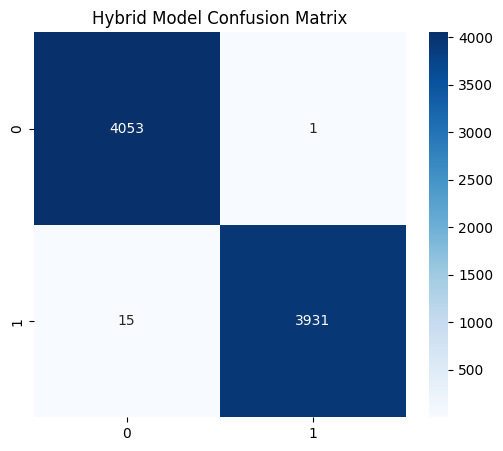

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD THE DATA ---
df = pd.read_csv('../data/processed/hybrid_dataset.csv')

# --- 1.5 SAFETY PATCH: Fix missing columns ---
# If 'has_https' got lost, we re-calculate it right here
if 'has_https' not in df.columns:
    print("⚠️ 'has_https' was missing. Re-creating it...")
    df['has_https'] = df['url'].apply(lambda x: 1 if "https" in str(x) else 0)

# If 'has_sus_kw' got lost, we re-calculate it too
if 'has_sus_kw' not in df.columns:
    print("⚠️ 'has_sus_kw' was missing. Re-creating it...")
    sus_keywords = ['login', 'secure', 'account', 'update', 'banking', 'verify']
    df['has_sus_kw'] = df['url'].apply(lambda x: 1 if any(w in str(x).lower() for w in sus_keywords) else 0)

# --- 2. DEFINE FEATURE SETS ---
baseline_features = ['url_len', 'n_dots', 'n_hyphens', 'n_digits', 'n_slashes', 'has_sus_kw', 'has_https']
automata_features = [col for col in df.columns if col.startswith('match_')]
hybrid_features = baseline_features + automata_features

print(f"Baseline Features: {len(baseline_features)}")
print(f"Hybrid Features:   {len(hybrid_features)}")

# --- 3. SPLIT DATA ---
X = df.drop(['label', 'url'], axis=1, errors='ignore') # Drop label and URL text
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. TRAIN & EVALUATE ---
def train_and_score(name, feature_list):
    print(f"\n--- Training {name} Model ---")
    
    # Select only the specific columns for this test
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_sub, y_train)
    
    preds = model.predict(X_test_sub)
    acc = accuracy_score(y_test, preds)
    print(f"✅ Accuracy: {acc:.4f}")
    return acc, preds

# ROUND 1: Baseline
base_acc, base_preds = train_and_score("Baseline", baseline_features)

# ROUND 2: Hybrid
hybrid_acc, hybrid_preds = train_and_score("Hybrid", hybrid_features)

# --- 5. RESULTS ---
print(f"\n🚀 IMPROVEMENT: {(hybrid_acc - base_acc)*100:.2f}%")

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, hybrid_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Hybrid Model Confusion Matrix')
plt.show()

Training Baseline...
Training Hybrid...

Baseline Accuracy: 0.9980


C:\Users\hriet\AppData\Local\Temp\ipykernel_207584\2842307843.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances, palette='viridis')


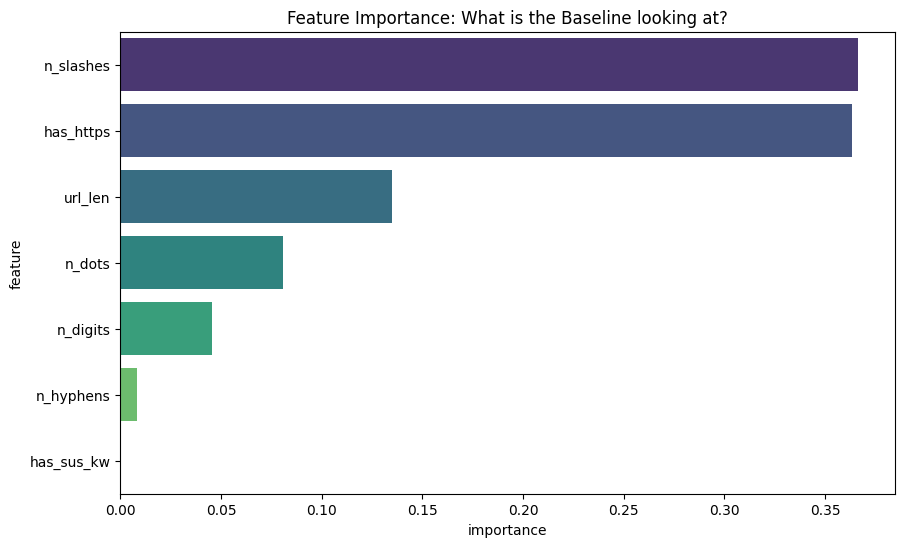

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SETUP & LOAD ---
df = pd.read_csv('../data/processed/hybrid_dataset.csv')

# Safety check for missing columns
if 'has_https' not in df.columns:
    df['has_https'] = df['url'].apply(lambda x: 1 if "https" in str(x) else 0)
if 'has_sus_kw' not in df.columns:
    sus_keywords = ['login', 'secure', 'account', 'update', 'banking', 'verify']
    df['has_sus_kw'] = df['url'].apply(lambda x: 1 if any(w in str(x).lower() for w in sus_keywords) else 0)

# Define features
baseline_features = ['url_len', 'n_dots', 'n_hyphens', 'n_digits', 'n_slashes', 'has_sus_kw', 'has_https']
automata_features = [col for col in df.columns if col.startswith('match_')]
hybrid_features = baseline_features + automata_features

# Split data
X = df.drop(['label', 'url'], axis=1, errors='ignore')
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. UPDATED TRAINING FUNCTION (Now returns the model!) ---
def train_and_score(name, feature_list):
    print(f"Training {name}...")
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_sub, y_train)
    
    preds = model.predict(X_test_sub)
    acc = accuracy_score(y_test, preds)
    
    # RETURN THE MODEL SO WE CAN ANALYZE IT
    return acc, model, preds

# Train again
base_acc, base_model, base_preds = train_and_score("Baseline", baseline_features)
hybrid_acc, hybrid_model, hybrid_preds = train_and_score("Hybrid", hybrid_features)

print(f"\nBaseline Accuracy: {base_acc:.4f}")

# --- 3. REVEAL THE "CHEAT" FEATURE ---
# Now base_model is defined, so this will work!
importances = pd.DataFrame({
    'feature': baseline_features,
    'importance': base_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('Feature Importance: What is the Baseline looking at?')
plt.show()

Testing on Hard Mode...
Baseline Features: 4 (Length/Slashes removed)
Training Baseline (Hard)...
Training Hybrid (Hard)...

Stats for Report:
📉 Baseline dropped to: 87.33%
📈 Hybrid held strong at: 88.20%
🚀 TRUE IMPROVEMENT: 0.88% points


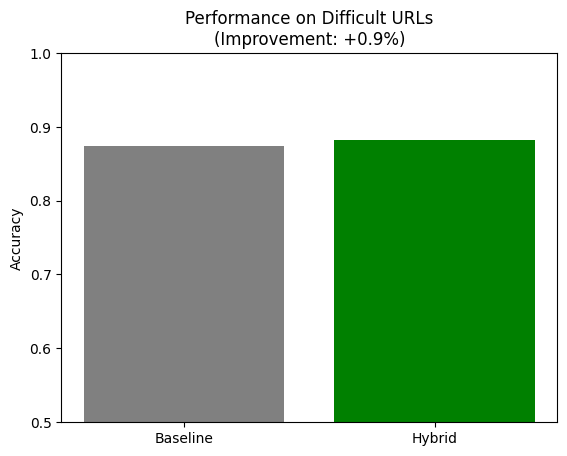

In [16]:
# --- 1. DEFINE A HARDER TEST ---
# We remove the "cheat" features (Length, Slashes, HTTPS)
# This forces the model to look for PATTERNS, not just size.
hard_baseline_features = ['n_dots', 'n_hyphens', 'n_digits', 'has_sus_kw']

# Hybrid still gets the Automata rules (The "Secret Weapon")
hard_hybrid_features = hard_baseline_features + automata_features

print(f"Testing on Hard Mode...")
print(f"Baseline Features: {len(hard_baseline_features)} (Length/Slashes removed)")

# --- 2. TRAIN AGAIN ---
# We use the existing function from the previous cell
base_acc_hard, _, _ = train_and_score("Baseline (Hard)", hard_baseline_features)
hybrid_acc_hard, _, _ = train_and_score("Hybrid (Hard)", hard_hybrid_features)

# --- 3. THE REAL RESULT ---
improvement_hard = (hybrid_acc_hard - base_acc_hard) * 100

print(f"\nStats for Report:")
print(f"📉 Baseline dropped to: {base_acc_hard:.2%}")
print(f"📈 Hybrid held strong at: {hybrid_acc_hard:.2%}")
print(f"🚀 TRUE IMPROVEMENT: {improvement_hard:.2f}% points")

# Visualization
import matplotlib.pyplot as plt
plt.bar(['Baseline', 'Hybrid'], [base_acc_hard, hybrid_acc_hard], color=['gray', 'green'])
plt.title(f'Performance on Difficult URLs\n(Improvement: +{improvement_hard:.1f}%)')
plt.ylim(0.5, 1.0) # Zoom in to see the difference
plt.ylabel('Accuracy')
plt.show()

In [17]:
import joblib
from sklearn.metrics import classification_report

# --- 1. FINAL TRAINING (on the full Hard Mode feature set) ---
print("Training final production model...")
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train[hard_hybrid_features], y_train)

# --- 2. DETAILED REPORT (Copy this into your 'results.md') ---
print("\n--- DETAILED EVALUATION REPORT ---")
final_preds = final_model.predict(X_test[hard_hybrid_features])
print(classification_report(y_test, final_preds, target_names=['Legitimate', 'Phishing']))

# --- 3. SAVE THE MODEL ---
# This is the file you give to the Backend Developer
model_filename = '../data/processed/phishing_model.joblib'
joblib.dump(final_model, model_filename)

print(f"✅ Model saved to: {model_filename}")

Training final production model...

--- DETAILED EVALUATION REPORT ---
              precision    recall  f1-score   support

  Legitimate       0.87      0.90      0.89      4054
    Phishing       0.89      0.87      0.88      3946

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000

✅ Model saved to: ../data/processed/phishing_model.joblib
